# 相位编码（Phase Coding）测试

测试 `phase_encode` 函数：验证膜电位越大，脉冲越早发放的特性

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('/Users/S4142196/Documents/Phd_Document/codes/TPP_QCFS')
from Models.DualVGG import phase_encode

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cpu


## 测试1: 一维膜电位（全连接层）

In [2]:
# 测试参数
T = 8  # 时间步数
thre = 8.0  # 阈值

# 创建测试数据：不同大小的膜电位 [B=1, N=5]
# 膜电位值：[10, 8, 5, 2, 0] - 从大到小
mem = torch.tensor([[16.0, 12.0, 10.0, 7.0, 4.0]], device=device)  # [1, 5]

print("膜电位值:", mem.squeeze().cpu().numpy())
print("\n预期行为: 膜电位越大，脉冲越早发放")

# 执行相位编码
spike_seq = phase_encode(mem, T, thre, device)  # [T, B, N] = [8, 1, 5]

# 转换为numpy以便可视化
spike_seq_np = spike_seq.squeeze(1).cpu().numpy()  # [T, N] = [8, 5]

print("\n脉冲序列 (行=时间步, 列=神经元):")
print(spike_seq_np)
print("\n脉冲时间 (每个神经元发放脉冲的时间步):")
for n in range(5):
    spike_times = np.where(spike_seq_np[:, n] > 0)[0]
    if len(spike_times) > 0:
        print(f"神经元 {n} (mem={mem[0, n].item():.1f}): 时间步 {spike_times[0]}")
    else:
        print(f"神经元 {n} (mem={mem[0, n].item():.1f}): 无脉冲")

膜电位值: [16. 12. 10.  7.  4.]

预期行为: 膜电位越大，脉冲越早发放

脉冲序列 (行=时间步, 列=神经元):
[[8. 0. 0. 0. 0.]
 [0. 8. 0. 0. 0.]
 [0. 0. 8. 0. 0.]
 [0. 0. 0. 8. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 8.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

脉冲时间 (每个神经元发放脉冲的时间步):
神经元 0 (mem=16.0): 时间步 0
神经元 1 (mem=12.0): 时间步 1
神经元 2 (mem=10.0): 时间步 2
神经元 3 (mem=7.0): 时间步 3
神经元 4 (mem=4.0): 时间步 5


/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/480193621.py:35: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/480193621.py:35: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/480193621.py:35: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/480193621.py:35: UserWarning: Glyph 31070 (\N{CJK UNIFIED IDEOGRAPH-795E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/480193621.py:35: UserWarning: Glyph 32463 (\N{CJK UNIFIED IDEOGRAPH-7ECF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454

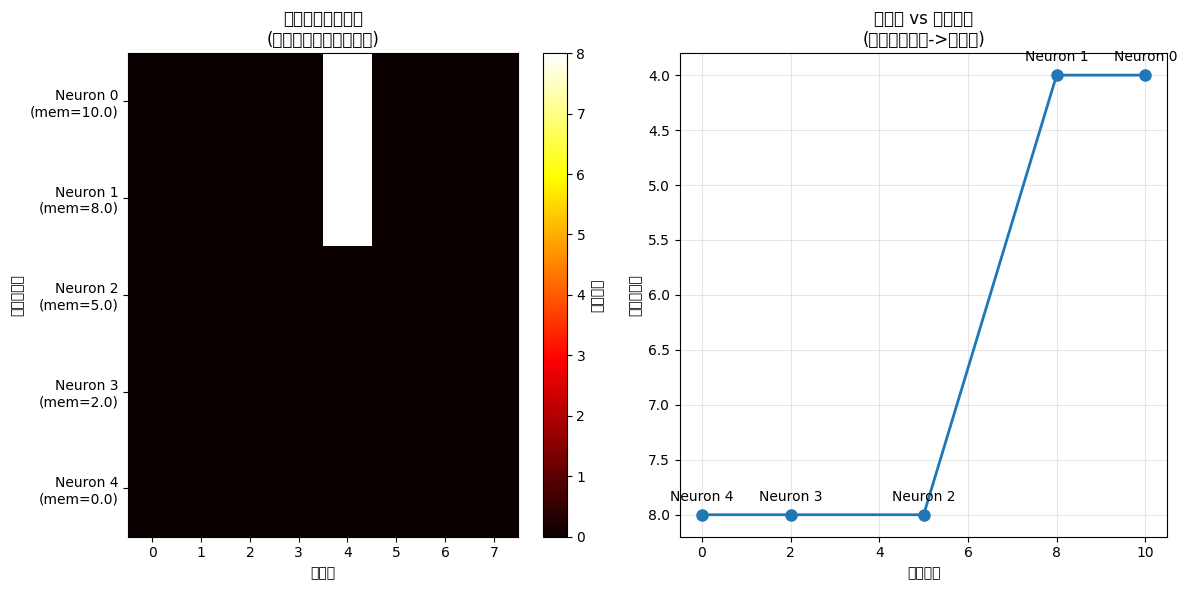


验证: 膜电位越大，脉冲时间步越小（越早发放）


In [9]:
# 可视化脉冲序列
plt.figure(figsize=(12, 6))

# 子图1: 脉冲序列热图
plt.subplot(1, 2, 1)
plt.imshow(spike_seq_np.T, aspect='auto', cmap='hot', interpolation='nearest')
plt.colorbar(label='脉冲幅度')
plt.xlabel('时间步')
plt.ylabel('神经元索引')
plt.title('相位编码脉冲序列\n(膜电位越大，脉冲越早)')
plt.yticks(range(5), [f'Neuron {i}\n(mem={mem[0, i].item():.1f})' for i in range(5)])

# 子图2: 脉冲时间 vs 膜电位
plt.subplot(1, 2, 2)
mem_values = mem.squeeze().cpu().numpy()
spike_times = []
for n in range(5):
    times = np.where(spike_seq_np[:, n] > 0)[0]
    if len(times) > 0:
        spike_times.append(times[0])
    else:
        spike_times.append(T)  # 如果没有脉冲，设为T（超出范围）

plt.plot(mem_values, spike_times, 'o-', linewidth=2, markersize=8)
plt.xlabel('膜电位值')
plt.ylabel('脉冲时间步')
plt.title('膜电位 vs 脉冲时间\n(负相关：大值->早脉冲)')
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()  # 反转y轴，使早的时间步在顶部

for i, (mem_val, spike_time) in enumerate(zip(mem_values, spike_times)):
    plt.annotate(f'Neuron {i}', (mem_val, spike_time), 
                textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

print("\n验证: 膜电位越大，脉冲时间步越小（越早发放）")

## 测试2: 二维膜电位（卷积层）

In [10]:
# 创建2D测试数据 [B=1, C=1, H=3, W=3]
# 创建一个3x3的膜电位矩阵，值从大到小
mem_2d = torch.tensor([[[[10.0, 8.0, 6.0],
                         [5.0, 3.0, 2.0],
                         [1.0, 0.5, 0.0]]]], device=device)  # [1, 1, 3, 3]

print("膜电位矩阵 (3x3):")
print(mem_2d.squeeze().cpu().numpy())

# 执行相位编码
spike_seq_2d = phase_encode(mem_2d, T, thre, device)  # [T, B, C, H, W] = [8, 1, 1, 3, 3]

# 提取第一个通道的第一个样本
spike_seq_2d_np = spike_seq_2d[:, 0, 0, :, :].cpu().numpy()  # [T, H, W] = [8, 3, 3]

print("\n每个位置脉冲发放的时间步:")
for h in range(3):
    for w in range(3):
        mem_val = mem_2d[0, 0, h, w].item()
        spike_times = np.where(spike_seq_2d_np[:, h, w] > 0)[0]
        if len(spike_times) > 0:
            print(f"位置 ({h}, {w}) mem={mem_val:4.1f}: 时间步 {spike_times[0]}")
        else:
            print(f"位置 ({h}, {w}) mem={mem_val:4.1f}: 无脉冲")

膜电位矩阵 (3x3):
[[10.   8.   6. ]
 [ 5.   3.   2. ]
 [ 1.   0.5  0. ]]

每个位置脉冲发放的时间步:
位置 (0, 0) mem=10.0: 时间步 4
位置 (0, 1) mem= 8.0: 时间步 4
位置 (0, 2) mem= 6.0: 无脉冲
位置 (1, 0) mem= 5.0: 无脉冲
位置 (1, 1) mem= 3.0: 无脉冲
位置 (1, 2) mem= 2.0: 无脉冲
位置 (2, 0) mem= 1.0: 无脉冲
位置 (2, 1) mem= 0.5: 无脉冲
位置 (2, 2) mem= 0.0: 无脉冲


/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/1034782745.py:21: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/1034782745.py:21: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/1034782745.py:21: UserWarning: Glyph 27493 (\N{CJK UNIFIED IDEOGRAPH-6B65}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/1034782745.py:21: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/1034782745.py:21: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92

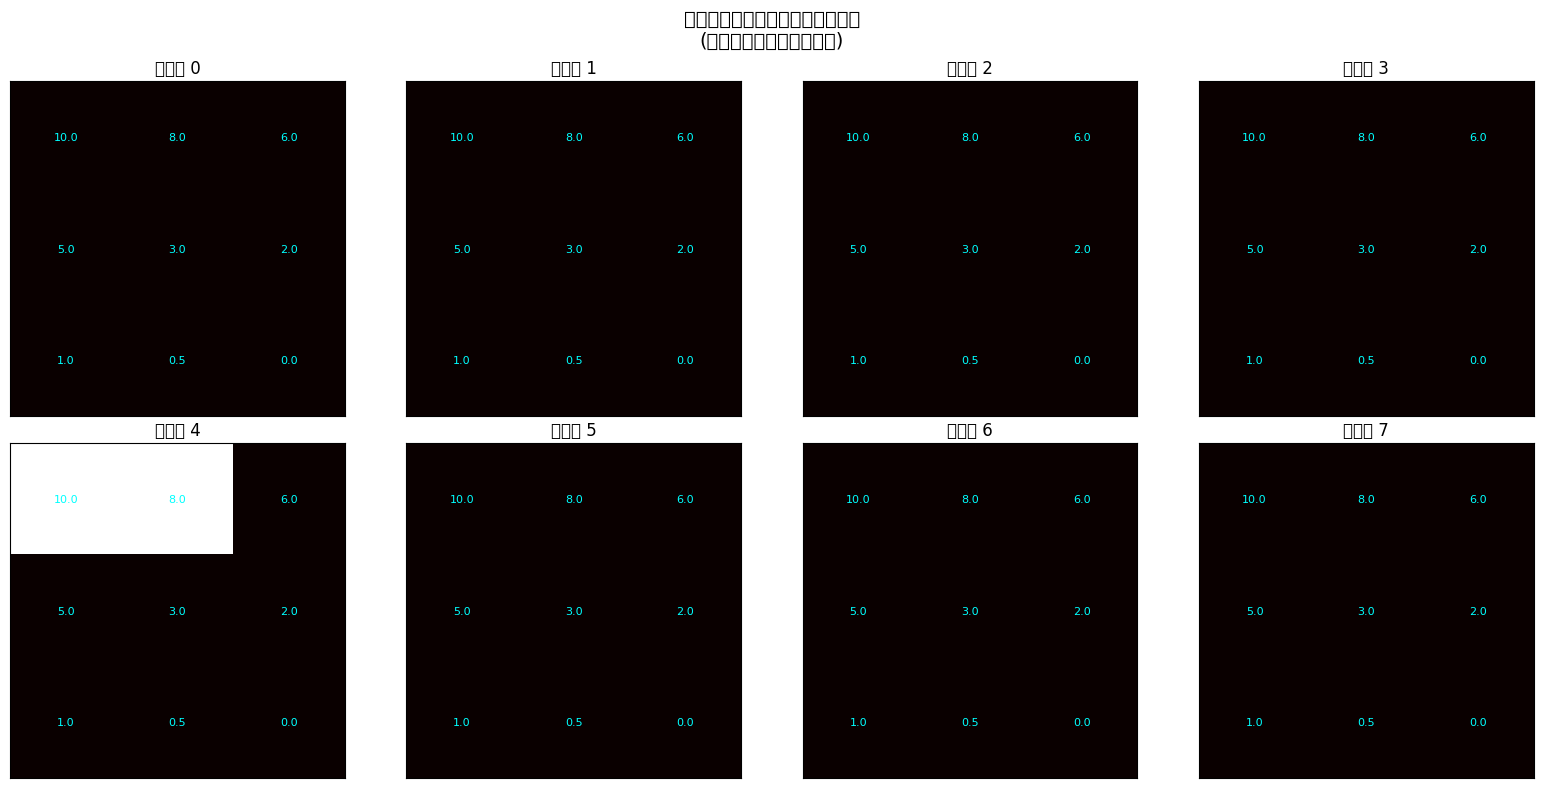

/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/1034782745.py:48: UserWarning: Glyph 33180 (\N{CJK UNIFIED IDEOGRAPH-819C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/1034782745.py:48: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/1034782745.py:48: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/1034782745.py:48: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92jc454s1648p3g1z477w80000gp/T/ipykernel_23316/1034782745.py:48: UserWarning: Glyph 33033 (\N{CJK UNIFIED IDEOGRAPH-8109}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l_/cw92

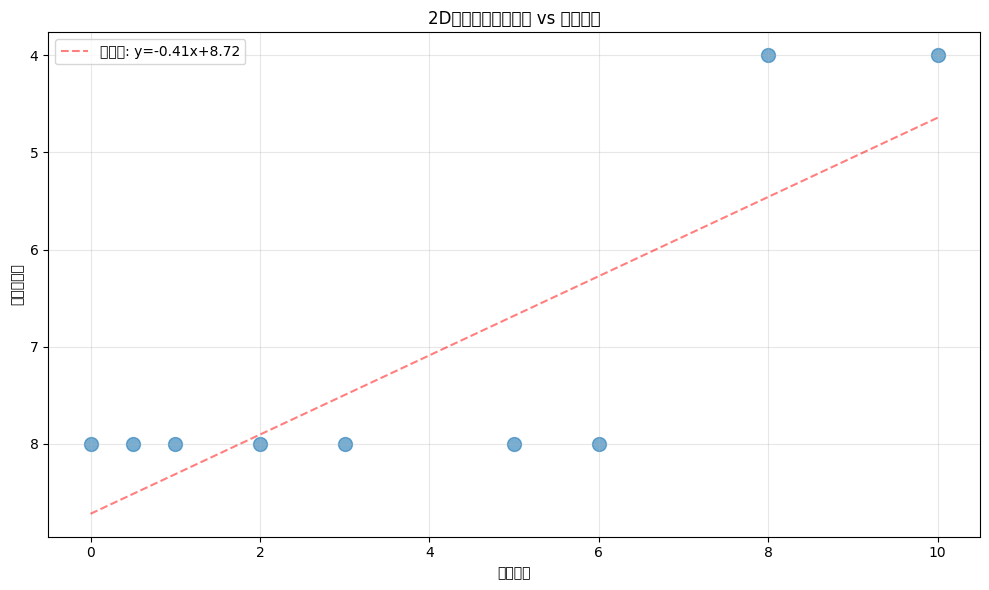


验证: 膜电位越大，脉冲时间步越小（负相关）


In [11]:
# 可视化2D相位编码
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# 显示每个时间步的脉冲模式
for t in range(T):
    ax = axes[t]
    im = ax.imshow(spike_seq_2d_np[t], cmap='hot', vmin=0, vmax=thre)
    ax.set_title(f'时间步 {t}')
    ax.set_xticks([])
    ax.set_yticks([])
    
    # 在每个位置显示膜电位值
    mem_vals = mem_2d[0, 0].cpu().numpy()
    for h in range(3):
        for w in range(3):
            text = ax.text(w, h, f'{mem_vals[h, w]:.1f}',
                         ha="center", va="center", color="cyan", fontsize=8)

plt.suptitle('相位编码：每个时间步的脉冲模式\n(膜电位值显示为青色数字)', fontsize=14)
plt.tight_layout()
plt.show()

# 显示脉冲时间分布
plt.figure(figsize=(10, 6))
mem_flat = mem_2d.squeeze().cpu().numpy().flatten()
spike_times_flat = []
for idx in range(9):
    h, w = idx // 3, idx % 3
    times = np.where(spike_seq_2d_np[:, h, w] > 0)[0]
    if len(times) > 0:
        spike_times_flat.append(times[0])
    else:
        spike_times_flat.append(T)

plt.scatter(mem_flat, spike_times_flat, s=100, alpha=0.6)
plt.xlabel('膜电位值')
plt.ylabel('脉冲时间步')
plt.title('2D相位编码：膜电位 vs 脉冲时间')
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()

# 添加趋势线
z = np.polyfit(mem_flat, spike_times_flat, 1)
p = np.poly1d(z)
plt.plot(mem_flat, p(mem_flat), "r--", alpha=0.5, label=f'趋势线: y={z[0]:.2f}x+{z[1]:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

print("\n验证: 膜电位越大，脉冲时间步越小（负相关）")

## 测试3: 边界情况

In [6]:
# 测试边界情况
print("=== 测试边界情况 ===\n")

# 情况1: 所有膜电位相同
mem_same = torch.ones(1, 5, device=device) * 5.0
spike_same = phase_encode(mem_same, T, thre, device)
print("1. 所有膜电位相同 (mem=5.0):")
for n in range(5):
    times = np.where(spike_same[:, 0, n].cpu().numpy() > 0)[0]
    print(f"   神经元 {n}: 时间步 {times[0] if len(times) > 0 else '无'}")

# 情况2: 膜电位为0
mem_zero = torch.zeros(1, 5, device=device)
spike_zero = phase_encode(mem_zero, T, thre, device)
print("\n2. 所有膜电位为0:")
spike_count = (spike_zero > 0).sum().item()
print(f"   脉冲总数: {spike_count} (应该为0)")

# 情况3: 膜电位很大（超过阈值）
mem_large = torch.tensor([[20.0, 15.0, 10.0, 5.0, 0.0]], device=device)
spike_large = phase_encode(mem_large, T, thre, device)
print("\n3. 膜电位很大 (mem=[20, 15, 10, 5, 0]):")
for n in range(5):
    mem_val = mem_large[0, n].item()
    times = np.where(spike_large[:, 0, n].cpu().numpy() > 0)[0]
    print(f"   神经元 {n} (mem={mem_val:4.1f}): 时间步 {times[0] if len(times) > 0 else '无'}")

# 情况4: 每个神经元只发放一个脉冲
print("\n4. 验证每个神经元只发放一个脉冲:")
mem_test = torch.tensor([[10.0, 8.0, 5.0, 2.0, 0.0]], device=device)
spike_test = phase_encode(mem_test, T, thre, device)
for n in range(5):
    spike_count = (spike_test[:, 0, n] > 0).sum().item()
    print(f"   神经元 {n}: {spike_count} 个脉冲 (应该为1或0)")

=== 测试边界情况 ===

1. 所有膜电位相同 (mem=5.0):
   神经元 0: 时间步 无
   神经元 1: 时间步 无
   神经元 2: 时间步 无
   神经元 3: 时间步 无
   神经元 4: 时间步 无

2. 所有膜电位为0:
   脉冲总数: 0 (应该为0)

3. 膜电位很大 (mem=[20, 15, 10, 5, 0]):
   神经元 0 (mem=20.0): 时间步 0
   神经元 1 (mem=15.0): 时间步 4
   神经元 2 (mem=10.0): 时间步 4
   神经元 3 (mem= 5.0): 时间步 无
   神经元 4 (mem= 0.0): 时间步 无

4. 验证每个神经元只发放一个脉冲:
   神经元 0: 1 个脉冲 (应该为1或0)
   神经元 1: 1 个脉冲 (应该为1或0)
   神经元 2: 0 个脉冲 (应该为1或0)
   神经元 3: 0 个脉冲 (应该为1或0)
   神经元 4: 0 个脉冲 (应该为1或0)


## 测试4: 相位编码的正确性验证

# DualVGG 测试

测试 `DualVGG._get_layer_mem` 方法：验证在传播过程中获取层膜电位的功能

In [1]:
import torch
import sys
sys.path.append('/Users/S4142196/Documents/Phd_Document/codes/TPP_QCFS')
from Models.DualVGG import DualVGG
from Models.layer import add_dimention

# 设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 创建DualVGG模型
model = DualVGG(vgg_name='VGG16', num_classes=10, dropout=0.5, fusion_method='concat')
model = model.to(device)
print("DualVGG模型创建成功")

使用设备: cpu
DualVGG模型创建成功


## 测试1: 获取第一层膜电位（T > 0，SNN模式）

In [2]:
# 设置时间步数
T = 8
model.set_T(T)
print(f"设置时间步数: T = {T}")

# 创建测试输入 [B, C, H, W]
B, C, H, W = 2, 3, 32, 32
x = torch.randn(B, C, H, W, device=device)
print(f"输入形状: {x.shape}")

# 准备输入（扩展时间维度并合并）
x_main = add_dimention(x, T)  # [T, B, C, H, W]
x_main = model.main_vgg.merge(x_main)  # [T*B, C, H, W]
print(f"处理后的输入形状: {x_main.shape}")

# 获取第一层膜电位
mem, thre, output = model._get_layer_mem(x_main, model.main_vgg.layer1)

print(f"\n=== 第一层膜电位信息 ===")
print(f"膜电位形状: {mem.shape if mem is not None else None}")
print(f"阈值: {thre.item() if thre is not None else None}")
print(f"层输出形状: {output.shape}")

# 验证膜电位的合理性
if mem is not None:
    print(f"\n膜电位统计:")
    print(f"  最小值: {mem.min().item():.4f}")
    print(f"  最大值: {mem.max().item():.4f}")
    print(f"  平均值: {mem.mean().item():.4f}")
    print(f"  标准差: {mem.std().item():.4f}")
    
    # 验证膜电位应该是非负的（因为IF神经元累加输入）
    if (mem < 0).any():
        print("⚠️  警告: 膜电位中存在负值")
    else:
        print("✓ 膜电位均为非负值（符合预期）")
else:
    print("⚠️  警告: 未能获取膜电位")

class VGG called
class VGG called
设置时间步数: T = 8
输入形状: torch.Size([2, 3, 32, 32])
处理后的输入形状: torch.Size([16, 3, 32, 32])

=== 第一层膜电位信息 ===
膜电位形状: torch.Size([2, 64, 32, 32])
阈值: 8.0
层输出形状: torch.Size([16, 64, 16, 16])

膜电位统计:
  最小值: -34.1220
  最大值: 11.7667
  平均值: 1.3834
  标准差: 5.3144
⚠️  警告: 膜电位中存在负值


## 测试2: 获取第二层膜电位

In [3]:
# 使用第一层的输出作为第二层的输入
layer1_mem, layer1_thre, layer1_out = model._get_layer_mem(x_main, model.main_vgg.layer1)

# 获取第二层膜电位
layer2_mem, layer2_thre, layer2_out = model._get_layer_mem(layer1_out, model.main_vgg.layer2)

print(f"=== 第二层膜电位信息 ===")
print(f"膜电位形状: {layer2_mem.shape if layer2_mem is not None else None}")
print(f"阈值: {layer2_thre.item() if layer2_thre is not None else None}")
print(f"层输出形状: {layer2_out.shape}")

if layer2_mem is not None:
    print(f"\n第二层膜电位统计:")
    print(f"  最小值: {layer2_mem.min().item():.4f}")
    print(f"  最大值: {layer2_mem.max().item():.4f}")
    print(f"  平均值: {layer2_mem.mean().item():.4f}")
    
    # 比较第一层和第二层的膜电位
    if layer1_mem is not None:
        print(f"\n第一层 vs 第二层膜电位:")
        print(f"  第一层平均值: {layer1_mem.mean().item():.4f}")
        print(f"  第二层平均值: {layer2_mem.mean().item():.4f}")
        print(f"  第一层阈值: {layer1_thre.item():.4f}")
        print(f"  第二层阈值: {layer2_thre.item():.4f}")

=== 第二层膜电位信息 ===
膜电位形状: torch.Size([2, 128, 16, 16])
阈值: 8.0
层输出形状: torch.Size([16, 128, 8, 8])

第二层膜电位统计:
  最小值: -8.6002
  最大值: 12.4386
  平均值: 3.4901

第一层 vs 第二层膜电位:
  第一层平均值: 1.3834
  第二层平均值: 3.4901
  第一层阈值: 8.0000
  第二层阈值: 8.0000


## 测试3: T=0模式（ANN模式）

In [4]:
# 设置T=0（ANN模式）
model.set_T(0)
print(f"设置时间步数: T = 0 (ANN模式)")

# 创建测试输入
x_ann = torch.randn(B, C, H, W, device=device)

# 获取第一层膜电位（T=0时，膜电位就是输入）
mem_ann, thre_ann, output_ann = model._get_layer_mem(x_ann, model.main_vgg.layer1)

print(f"\n=== ANN模式下的第一层信息 ===")
print(f"膜电位形状: {mem_ann.shape if mem_ann is not None else None}")
print(f"阈值: {thre_ann.item() if thre_ann is not None else None}")
print(f"层输出形状: {output_ann.shape}")

if mem_ann is not None:
    print(f"\n膜电位统计:")
    print(f"  最小值: {mem_ann.min().item():.4f}")
    print(f"  最大值: {mem_ann.max().item():.4f}")
    print(f"  平均值: {mem_ann.mean().item():.4f}")
    
    # 在T=0模式下，膜电位应该等于IF层的输入
    print(f"\n✓ T=0模式下，膜电位直接使用输入（符合预期）")

class VGG called
class VGG called
设置时间步数: T = 0 (ANN模式)

=== ANN模式下的第一层信息 ===
膜电位形状: torch.Size([2, 64, 32, 32])
阈值: None
层输出形状: torch.Size([2, 64, 16, 16])

膜电位统计:
  最小值: -4.5791
  最大值: 4.3947
  平均值: -0.0000

✓ T=0模式下，膜电位直接使用输入（符合预期）


## 测试4: 验证避免重复计算

In [5]:
# 恢复SNN模式
# 设置模型为评估模式（禁用Dropout的随机性）
model.eval()
torch.manual_seed(42)  # 设置随机种子以确保可重复性
model.set_T(8)

# 测试：获取膜电位后，继续使用输出进行传播
x_test = torch.randn(B, C, H, W, device=device)
x_test_main = add_dimention(x_test, T)
x_test_main = model.main_vgg.merge(x_test_main)

# 方法1: 使用_get_layer_mem获取膜电位和输出
mem_test, thre_test, layer1_out_test = model._get_layer_mem(x_test_main, model.main_vgg.layer1)

# 方法2: 直接调用layer1（用于对比）
layer1_out_direct = model.main_vgg.layer1(x_test_main)

# 验证两种方法得到的输出是否一致
if torch.allclose(layer1_out_test, layer1_out_direct, atol=1e-5):
    print("✓ 验证通过: _get_layer_mem返回的输出与直接调用layer1的输出一致")
    print("  说明在获取膜电位的同时，正确计算了层输出，避免了重复计算")
else:
    print("⚠️  警告: 输出不一致")
    print(f"  差异: {(layer1_out_test - layer1_out_direct).abs().max().item():.6f}")

print(f"\n膜电位已成功获取: {mem_test is not None}")
print(f"输出形状一致: {layer1_out_test.shape == layer1_out_direct.shape}")

class VGG called
class VGG called
✓ 验证通过: _get_layer_mem返回的输出与直接调用layer1的输出一致
  说明在获取膜电位的同时，正确计算了层输出，避免了重复计算

膜电位已成功获取: True
输出形状一致: True


## 测试5: 完整前向传播测试

In [20]:
# 测试完整的DualVGG前向传播
model.set_T(8)
model.eval()  # 设置为评估模式，确保Dropout等层的行为一致

# 创建测试输入
x_full = torch.randn(B, C, H, W, device=device)
print(f"输入形状: {x_full.shape}")

print("\n开始完整前向传播...")
try:
    with torch.no_grad():  # 禁用梯度计算，节省内存
        output = model(x_full)
    
    print(f"✓ 前向传播成功")
    print(f"\n输出信息:")
    print(f"  形状: {output.shape}")
    print(f"  统计:")
    print(f"    最小值: {output.min().item():.4f}")
    print(f"    最大值: {output.max().item():.4f}")
    print(f"    平均值: {output.mean().item():.4f}")
    print(f"    标准差: {output.std().item():.4f}")
    
    # 验证输出形状应该是 [B, num_classes]
    expected_shape = (B, 10)
    if output.shape == expected_shape:
        print(f"\n✓ 输出形状正确: {output.shape} == {expected_shape}")
    else:
        print(f"\n⚠️  输出形状不匹配: {output.shape} != {expected_shape}")
    
    # 验证输出是否包含有效值（不是全0或全NaN）
    if torch.isnan(output).any():
        print("⚠️  警告: 输出中包含NaN值")
    elif (output == 0).all():
        print("⚠️  警告: 输出全为0")
    else:
        print("✓ 输出包含有效值")
    
    # 检查每个样本的输出是否不同（避免所有样本输出相同）
    if B > 1:
        output_diff = (output[0] - output[1]).abs().sum().item()
        if output_diff < 1e-6:
            print("⚠️  警告: 不同样本的输出几乎相同")
        else:
            print(f"✓ 不同样本的输出有差异 (差异: {output_diff:.4f})")
        
except Exception as e:
    print(f"❌ 前向传播失败: {e}")
    import traceback
    traceback.print_exc()

class VGG called
class VGG called
输入形状: torch.Size([2, 3, 32, 32])

开始完整前向传播...
✓ 前向传播成功

输出信息:
  形状: torch.Size([2, 10])
  统计:
    最小值: -0.3928
    最大值: 0.2559
    平均值: -0.0652
    标准差: 0.2176

✓ 输出形状正确: torch.Size([2, 10]) == (2, 10)
✓ 输出包含有效值
⚠️  警告: 不同样本的输出几乎相同


In [ ]:
# 检查Layer2的中间输出（正确版本）
print("\n=== 检查Layer2的中间输出（修正版） ===")
model.set_T(8)
model.eval()

x1 = torch.randn(1, 3, 32, 32, device=device)
x2 = torch.randn(1, 3, 32, 32, device=device)

with torch.no_grad():
    if model.T > 0:
        x1_main = add_dimention(x1, model.T)
        x1_main = model.main_vgg.merge(x1_main)
        x2_main = add_dimention(x2, model.T)
        x2_main = model.main_vgg.merge(x2_main)
    else:
        x1_main = x1
        x2_main = x2
    
    # 获取layer1输出
    _, _, layer1_out1 = model._get_layer_mem(x1_main, model.main_vgg.layer1)
    _, _, layer1_out2 = model._get_layer_mem(x2_main, model.main_vgg.layer1)
    
    # 手动遍历layer2，检查每个模块的输出
    temp1 = layer1_out1
    temp2 = layer1_out2
    
    print("Layer2各模块的输出统计:")
    for i, module in enumerate(model.main_vgg.layer2):
        # 在通过模块之前，保存当前值（用于IF的输入检查）
        if isinstance(module, IF):
            if_input1 = temp1.clone()  # IF的输入（BN的输出）
            if_input2 = temp2.clone()
            
            print(f"  模块{i} (IF, 阈值={module.thresh.data.item():.4f}):")
            print(f"    IF输入（BN的输出）:")
            print(f"      样本1: min={if_input1.min().item():.4f}, max={if_input1.max().item():.4f}, mean={if_input1.mean().item():.4f}")
            print(f"      样本2: min={if_input2.min().item():.4f}, max={if_input2.max().item():.4f}, mean={if_input2.mean().item():.4f}")
            
            # 检查IF的输入（展开时间维度）
            if model.T > 0:
                if_input1_expanded = model.main_vgg.expand(if_input1)  # [T, B, C, H, W]
                if_input2_expanded = model.main_vgg.expand(if_input2)
                print(f"    IF输入（展开后，每个时间步）:")
                print(f"      样本1: min={if_input1_expanded.min().item():.4f}, max={if_input1_expanded.max().item():.4f}")
                print(f"      样本2: min={if_input2_expanded.min().item():.4f}, max={if_input2_expanded.max().item():.4f}")
                
                # 估算膜电位累积（8个时间步，初始膜电位=0.5*阈值）
                mem_init = 0.5 * module.thresh.data.item()  # 4.0
                estimated_mem1 = mem_init + if_input1_expanded.sum(dim=0)  # 累积8个时间步
                estimated_mem2 = mem_init + if_input2_expanded.sum(dim=0)
                print(f"    估算膜电位（初始={mem_init:.4f} + 累积8个时间步后）:")
                print(f"      样本1: min={estimated_mem1.min().item():.4f}, max={estimated_mem1.max().item():.4f}, mean={estimated_mem1.mean().item():.4f}")
                print(f"      样本2: min={estimated_mem2.min().item():.4f}, max={estimated_mem2.max().item():.4f}, mean={estimated_mem2.mean().item():.4f}")
                print(f"      阈值: {module.thresh.data.item():.4f}")
                print(f"      是否超过阈值: 样本1={(estimated_mem1 > module.thresh.data.item()).any().item()}, 样本2={(estimated_mem2 > module.thresh.data.item()).any().item()}")
        
        # 通过模块
        temp1 = module(temp1)
        temp2 = module(temp2)
        
        # 显示模块输出（除了IF，因为上面已经显示了）
        if not isinstance(module, IF):
            if isinstance(module, nn.Conv2d):
                print(f"  模块{i} (Conv2d):")
                print(f"    样本1: min={temp1.min().item():.4f}, max={temp1.max().item():.4f}, mean={temp1.mean().item():.4f}")
                print(f"    样本2: min={temp2.min().item():.4f}, max={temp2.max().item():.4f}, mean={temp2.mean().item():.4f}")
            elif isinstance(module, nn.BatchNorm2d):
                print(f"  模块{i} (BatchNorm2d):")
                print(f"    样本1: min={temp1.min().item():.4f}, max={temp1.max().item():.4f}, mean={temp1.mean().item():.4f}")
                print(f"    样本2: min={temp2.min().item():.4f}, max={temp2.max().item():.4f}, mean={temp2.mean().item():.4f}")
        else:
            # IF的输出
            print(f"    IF输出:")
            print(f"      样本1: min={temp1.min().item():.4f}, max={temp1.max().item():.4f}, mean={temp1.mean().item():.4f}")
            print(f"      样本2: min={temp2.min().item():.4f}, max={temp2.max().item():.4f}, mean={temp2.mean().item():.4f}")


=== 检查Layer2的中间输出（修正版） ===
class VGG called
class VGG called
Layer2各模块的输出统计:
  模块0 (Conv2d):
    样本1: min=-2.0014, max=2.0301, mean=-0.0011
    样本2: min=-2.0942, max=1.9404, mean=-0.0013
  模块1 (BatchNorm2d):
    样本1: min=-2.0660, max=2.0837, mean=-0.0015
    样本2: min=-2.1531, max=1.9900, mean=-0.0017
  模块2 (IF, 阈值=8.0000):
    IF输入（BN的输出）:
      样本1: min=-2.0660, max=2.0837, mean=-0.0015
      样本2: min=-2.1531, max=1.9900, mean=-0.0017
    IF输入（展开后，每个时间步）:
      样本1: min=-2.0660, max=2.0837
      样本2: min=-2.1531, max=1.9900
    估算膜电位（初始=4.0000 + 累积8个时间步后）:
      样本1: min=1.2026, max=6.4139, mean=3.9883
      样本2: min=1.4773, max=6.5429, mean=3.9860
      阈值: 8.0000
      是否超过阈值: 样本1=False, 样本2=False
    IF输出:
      样本1: min=0.0000, max=0.0000, mean=0.0000
      样本2: min=0.0000, max=0.0000, mean=0.0000
  模块4 (Conv2d):
    样本1: min=-0.0283, max=0.0294, mean=0.0014
    样本2: min=-0.0283, max=0.0294, mean=0.0014
  模块5 (BatchNorm2d):
    样本1: min=-0.0460, max=0.0499, mean=-0.0006
    样本2: 

In [30]:
from Models.DualVGG import DualVGG,VGG
# 方式1：使用预训练的主网络和辅助网络
pretrained_main = VGG('VGG16', num_classes=10, dropout=0.5)
pretrained_aux = VGG('VGG16', num_classes=10, dropout=0.5)
# 加载预训练权重
pretrained_main.load_state_dict(torch.load('cifar100-checkpoints/vgg16_L[4].pth'))
pretrained_aux.load_state_dict(torch.load('cifar100-checkpoints/vgg16_L[4].pth'))

model = DualVGG(
    vgg_name='VGG16', 
    num_classes=10, 
    dropout=0.5, 
    fusion_method='concat',
    main_vgg=pretrained_main,  # 传入预训练的主网络
    aux_vgg=pretrained_aux      # 传入预训练的辅助网络
)

# 方式2：只传入预训练的辅助网络
pretrained_aux = VGG('VGG16', num_classes=10, dropout=0.5)
pretrained_aux.load_state_dict(torch.load('aux_vgg.pth'))

model = DualVGG(
    vgg_name='VGG16',
    num_classes=10,
    dropout=0.5,
    fusion_method='concat',
    aux_vgg=pretrained_aux  # 只传入预训练的辅助网络
)

# 方式3：使用默认方式（创建新的VGG）
model = DualVGG(
    vgg_name='VGG16',
    num_classes=10,
    dropout=0.5,
    fusion_method='concat'
)

RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.